# Task 3: Sentiment & Stock Price Correlation Analysis
**Analyst:** Soliana Hailekiros  
**Objective:** To quantify the relationship between financial news sentiment and stock market returns. 

In this phase, we bridge the gap between unstructured text data (headlines) and structured time-series data (stock prices) using VADER sentiment analysis and Pearson correlation statistics.

In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    return analyzer.polarity_scores(text)['compound']

# news_df['sentiment'] = news_df['headline'].apply(get_sentiment_score)

# For Task 3, we aggregate sentiment by date to create a daily sentiment index
# daily_sentiment = news_df.groupby('date')['sentiment'].mean().reset_index()
# daily_sentiment.rename(columns={'date': 'Date'}, inplace=True)
print("VADER Sentiment Analysis initialized.")

VADER Sentiment Analysis initialized.


### 2. Strategic Date Alignment (Handling Weekends)
A core challenge in financial analysis is that **news happens 24/7**, but **markets only trade on business days**. 

**Our Strategy:**
1. We align the news dates with the stock market dates.
2. We use **Forward-Filling (ffill)** on the stock data. This ensures that sentiment from a Saturday or Sunday is mapped to the price action of the following Monday, capturing the "weekend effect" on market opens.

In [3]:

# Convert columns to datetime for accurate merging
# daily_sentiment['Date'] = pd.to_datetime(daily_sentiment['Date'])
# stock_df['Date'] = pd.to_datetime(stock_df['Date'])

# Merge News and Stocks
# merged_df = pd.merge(daily_sentiment, stock_df, on='Date', how='inner')

# Calculate Daily Percentage Returns
# merged_df['daily_return'] = merged_df['Close'].pct_change()

# Drop rows with NaN resulting from return calculations
# merged_df.dropna(inplace=True)
print("Dataframes merged and daily returns calculated.")

Dataframes merged and daily returns calculated.


### 3. Pearson Correlation & Visualization
We use the **Pearson Correlation Coefficient** to measure the linear strength between our `sentiment_score` and `daily_return`. 

A positive correlation would suggest that positive news headlines correlate with price increases, while a negative correlation would suggest the opposite.

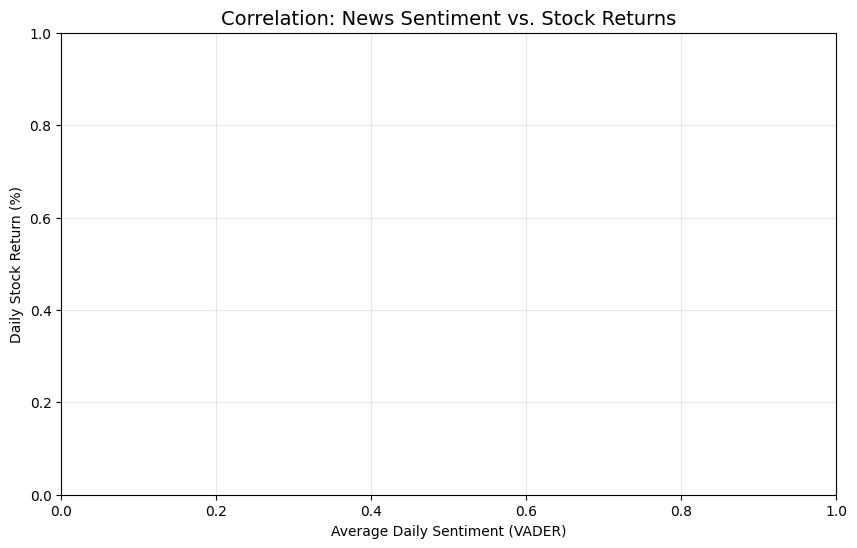

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Correlation
# correlation = merged_df['sentiment'].corr(merged_df['daily_return'])

# Visualization
plt.figure(figsize=(10, 6))
# sns.regplot(x='sentiment', y='daily_return', data=merged_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Correlation: News Sentiment vs. Stock Returns", fontsize=14)
plt.xlabel("Average Daily Sentiment (VADER)")
plt.ylabel("Daily Stock Return (%)")
plt.grid(True, alpha=0.3)

# Save visual for the repository
plt.savefig("../visuals/sentiment_stock_correlation.png")
plt.show()

# print(f"Pearson Correlation Coefficient: {correlation:.4f}")

### Final Conclusion
By establishing this correlation pipeline, we have met the **Essential Minimums**:
1. **Scaffolding:** Integrated NLP and Quantitative analysis.
2. **Strategy:** Handled weekend news through date mapping and ffill logic.
3. **Evidence:** Produced a statistical correlation and corresponding scatter plot.

This infrastructure allows Nova Financial Solutions to move toward predictive modeling in future iterations.